# **Analyse et Prédiction de LaLiga depuis la saison 2018-2019 — Projet de Data Mining**
Ali JAHMI

Ce notebook utilise les données officielles de la Liga de la saison 1993-1994 jusqu'à celle de 2024-2025. Différents traitements sont proposés, et peuvent être appliqués à chaque club :

*   visualisation de l'évolution des buts marqués et concédés par saison
*   visualisation des issues des matchs par saison
*   visualisation des statistiques de tirs, tirs cadrés et buts par saison
*   une visualisation de la corrélation entre les différentes données des fichiers csv
*   une prédiction avec machine learning du nombre de victoire d'une saison en utilisant toutes les statistiques sauf celles des issues des matchs
*   une comparaison avec une 2e équipe pour prédire le taux de victoire, ainsi que la cote du match



**I. Importation des données**

Import des librairies et fichiers .csv nécessaires au projet

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression

season_2425 = pd.read_csv("/content/data_projet/season-2425.csv")
season_2324 = pd.read_csv("/content/data_projet/season-2324.csv")
season_2223 = pd.read_csv("/content/data_projet/season-2223.csv")
season_2122 = pd.read_csv("/content/data_projet/season-2122.csv")
season_2021 = pd.read_csv("/content/data_projet/season-2021.csv")
season_1920 = pd.read_csv("/content/data_projet/season-1920.csv")
season_1819 = pd.read_csv("/content/data_projet/season-1819.csv")
season_1718 = pd.read_csv("/content/data_projet/season-1718.csv")
season_1617 = pd.read_csv("/content/data_projet/season-1617.csv")
season_1516 = pd.read_csv("/content/data_projet/season-1516.csv")
season_1415 = pd.read_csv("/content/data_projet/season-1415.csv")
season_1314 = pd.read_csv("/content/data_projet/season-1314.csv")
season_1213 = pd.read_csv("/content/data_projet/season-1213.csv")
season_1112 = pd.read_csv("/content/data_projet/season-1112.csv")
season_1011 = pd.read_csv("/content/data_projet/season-1011.csv")
season_0910 = pd.read_csv("/content/data_projet/season-0910.csv")
season_0809 = pd.read_csv("/content/data_projet/season-0809.csv")
season_0708 = pd.read_csv("/content/data_projet/season-0708.csv")
season_0607 = pd.read_csv("/content/data_projet/season-0607.csv")
season_0506 = pd.read_csv("/content/data_projet/season-0506.csv")
season_0405 = pd.read_csv("/content/data_projet/season-0405.csv")
season_0304 = pd.read_csv("/content/data_projet/season-0304.csv")
season_0203 = pd.read_csv("/content/data_projet/season-0203.csv")
season_0102 = pd.read_csv("/content/data_projet/season-0102.csv")
season_0001 = pd.read_csv("/content/data_projet/season-0001.csv")
season_9900 = pd.read_csv("/content/data_projet/season-9900.csv")
season_9899 = pd.read_csv("/content/data_projet/season-9899.csv")
season_9798 = pd.read_csv("/content/data_projet/season-9798.csv")
season_9697 = pd.read_csv("/content/data_projet/season-9697.csv")
season_9596 = pd.read_csv("/content/data_projet/season-9596.csv")
season_9495 = pd.read_csv("/content/data_projet/season-9495.csv")
season_9394 = pd.read_csv("/content/data_projet/season-9394.csv")

seasons = list(range(1993, 2025))

seasons_files = [
    season_9394, season_9495, season_9596, season_9697, season_9798,
    season_9899, season_9900, season_0001, season_0102, season_0203,
    season_0304, season_0405, season_0506, season_0607, season_0708,
    season_0809, season_0910, season_1011, season_1112, season_1213,
    season_1314, season_1415, season_1516, season_1617, season_1718,
    season_1819, season_1920, season_2021, season_2122, season_2223,
    season_2324, season_2425
]

**II. Première équipe**

Choix de la première équipe, l'équipe qui sera analysée

In [ ]:
team = input("Veuillez choisir une équipe ayant joué en Liga entre la saison 1993-1994 et 2024-2025 : ")

Veuillez choisir une équipe ayant joué en Liga entre la saison 1993-1994 et 2024-2025 : Ath Bilbao


**III. Récupérations des données**

Création de la liste dont chaque élément est un dictionnaire lié à une saison (donc à un fichier csv) de la première équipe suivi du remplissage de cette dernière avec des données issues des fichiers csv

In [ ]:
stats = []

for season in seasons:

  stats.append({
      "saison": season,
      "buts_marques_dom": 0,
      "buts_marques_ext": 0,
      "buts_marques_tot": 0,
      "buts_concedes_dom": 0,
      "buts_concedes_ext": 0,
      "buts_concedes_tot": 0,
      "tirs_dom": 0,
      "tirs_ext": 0,
      "tirs_tot": 0,
      "tirs_cadres_dom": 0,
      "tirs_cadres_ext": 0,
      "tirs_cadres_tot": 0,
      "tirs_cadres_concedes_dom": 0,
      "tirs_cadres_concedes_ext": 0,
      "tirs_cadres_concedes_tot": 0,
      "fautes_causees_dom": 0,
      "fautes_causees_ext": 0,
      "fautes_causees_tot": 0,
      "cartons_jaunes_neg_dom": 0,
      "cartons_jaunes_neg_ext": 0,
      "cartons_jaunes_neg_tot": 0,
      "cartons_rouges_neg_dom": 0,
      "cartons_rouges_neg_ext": 0,
      "cartons_rouges_neg_tot": 0,
      "cartons_jaunes_pos_dom": 0,
      "cartons_jaunes_pos_ext": 0,
      "cartons_jaunes_pos_tot": 0,
      "cartons_rouges_pos_dom": 0,
      "cartons_rouges_pos_ext": 0,
      "cartons_rouges_pos_tot": 0,
      "victoires_dom": 0,
      "victoires_ext": 0,
      "victoires_tot": 0,
      "defaites_dom": 0,
      "defaites_ext": 0,
      "defaites_tot": 0,
      "nuls_dom": 0,
      "nuls_ext": 0,
      "nuls_tot": 0,
  })

In [ ]:
def statistics(stats, team):

  season_counter = 0

  for season_file in seasons_files:

    season_file = season_file.drop(columns = "Referee")

    for i in range(len(season_file)):

      if season_file["HomeTeam"][i] == team:

        stats[season_counter]["buts_marques_dom"] += season_file["FTHG"][i]
        stats[season_counter]["buts_concedes_dom"] += season_file["FTAG"][i]
        stats[season_counter]["tirs_dom"] += season_file["HS"][i]
        stats[season_counter]["tirs_cadres_dom"] += season_file["HST"][i]
        stats[season_counter]["tirs_cadres_concedes_dom"] += season_file["AST"][i]
        stats[season_counter]["fautes_causees_dom"] += season_file["HF"][i]
        stats[season_counter]["cartons_jaunes_neg_dom"] += season_file["HY"][i]
        stats[season_counter]["cartons_rouges_neg_dom"] += season_file["HR"][i]
        stats[season_counter]["cartons_jaunes_pos_dom"] += season_file["AY"][i]
        stats[season_counter]["cartons_rouges_pos_dom"] += season_file["AR"][i]

        if season_file["FTR"][i] == "H":

          stats[season_counter]["victoires_dom"] += 1

        elif season_file["FTR"][i] == "D":

          stats[season_counter]["nuls_dom"] += 1

        else:

          stats[season_counter]["defaites_dom"] += 1

      if season_file["AwayTeam"][i] == team:

        stats[season_counter]["buts_marques_ext"] += season_file["FTAG"][i]
        stats[season_counter]["buts_concedes_ext"] += season_file["FTHG"][i]
        stats[season_counter]["tirs_ext"] += season_file["AS"][i]
        stats[season_counter]["tirs_cadres_ext"] += season_file["AST"][i]
        stats[season_counter]["tirs_cadres_concedes_ext"] += season_file["HST"][i]
        stats[season_counter]["fautes_causees_ext"] += season_file["AF"][i]
        stats[season_counter]["cartons_jaunes_neg_ext"] += season_file["AY"][i]
        stats[season_counter]["cartons_rouges_neg_ext"] += season_file["AR"][i]
        stats[season_counter]["cartons_jaunes_pos_ext"] += season_file["HY"][i]
        stats[season_counter]["cartons_rouges_pos_ext"] += season_file["HR"][i]

        if season_file["FTR"][i] == "A":

          stats[season_counter]["victoires_ext"] += 1

        elif season_file["FTR"][i] == "D":

          stats[season_counter]["nuls_ext"] += 1

        else:

          stats[season_counter]["defaites_ext"] += 1

    stats[season_counter]["buts_marques_tot"] = stats[season_counter]["buts_marques_dom"] + stats[season_counter]["buts_marques_ext"]
    stats[season_counter]["buts_concedes_tot"] = stats[season_counter]["buts_concedes_dom"] + stats[season_counter]["buts_concedes_ext"]
    stats[season_counter]["tirs_tot"] = stats[season_counter]["tirs_dom"] + stats[season_counter]["tirs_ext"]
    stats[season_counter]["fautes_causees_tot"] = stats[season_counter]["fautes_causees_dom"] + stats[season_counter]["fautes_causees_ext"]
    stats[season_counter]["tirs_cadres_tot"] = stats[season_counter]["tirs_cadres_dom"] + stats[season_counter]["tirs_cadres_ext"]
    stats[season_counter]["tirs_cadres_concedes_tot"] = stats[season_counter]["tirs_cadres_concedes_dom"] + stats[season_counter]["tirs_cadres_concedes_ext"]
    stats[season_counter]["cartons_jaunes_pos_tot"] = stats[season_counter]["cartons_jaunes_pos_dom"] + stats[season_counter]["cartons_jaunes_pos_ext"]
    stats[season_counter]["cartons_rouges_pos_tot"] = stats[season_counter]["cartons_rouges_pos_dom"] + stats[season_counter]["cartons_rouges_pos_ext"]
    stats[season_counter]["cartons_jaunes_neg_tot"] = stats[season_counter]["cartons_jaunes_neg_dom"] + stats[season_counter]["cartons_jaunes_neg_ext"]
    stats[season_counter]["cartons_rouges_neg_tot"] = stats[season_counter]["cartons_rouges_neg_dom"] + stats[season_counter]["cartons_rouges_neg_ext"]
    stats[season_counter]["victoires_tot"] = stats[season_counter]["victoires_dom"] + stats[season_counter]["victoires_ext"]
    stats[season_counter]["defaites_tot"] = stats[season_counter]["defaites_dom"] + stats[season_counter]["defaites_ext"]
    stats[season_counter]["nuls_tot"] = stats[season_counter]["nuls_dom"] + stats[season_counter]["nuls_ext"]

    season_counter += 1



statistics(stats, team)

**IV. Visualisation des données**

**1. Line graph de l'évolution des buts marqués et concédés saison après saison**

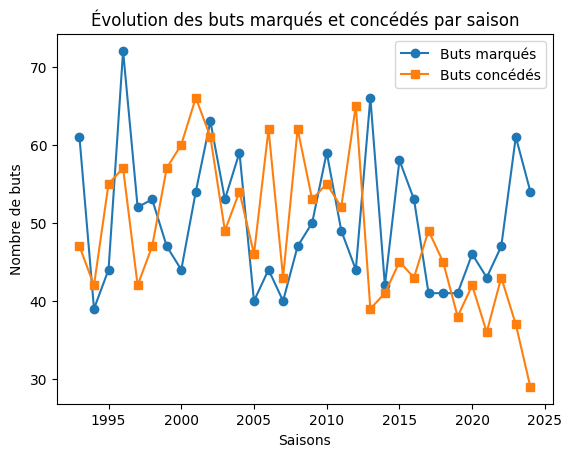

In [ ]:
df_stats = pd.DataFrame(stats)

plt.plot('saison', 'buts_marques_tot', data=df_stats, linestyle='-', marker='o', label="Buts marqués")
plt.plot('saison', 'buts_concedes_tot', data=df_stats, linestyle='-', marker='s', label="Buts concédés")
plt.xlabel("Saisons")
plt.ylabel("Nombre de buts")
plt.title("Évolution des buts marqués et concédés par saison")
plt.legend()
plt.show()

**2. Line graph de l'évolution des issues des matchs saison après saison**

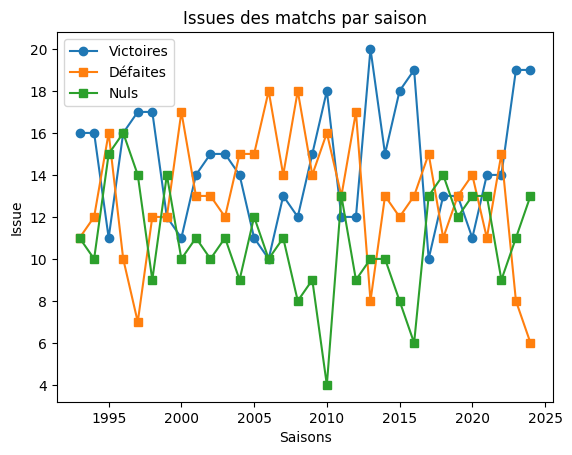

In [ ]:
df_stats = pd.DataFrame(stats)

plt.plot('saison', 'victoires_tot', data=df_stats, linestyle='-', marker='o', label="Victoires")
plt.plot('saison', 'defaites_tot', data=df_stats, linestyle='-', marker='s', label="Défaites")
plt.plot('saison', 'nuls_tot', data=df_stats, linestyle='-', marker='s', label="Nuls")
plt.xlabel("Saisons")
plt.ylabel("Issue")
plt.title("Issues des matchs par saison")
plt.legend()
plt.show()

**3. Stacked area chart sur la répartition des tirs, tirs cadrés et buts saison arpès saison**

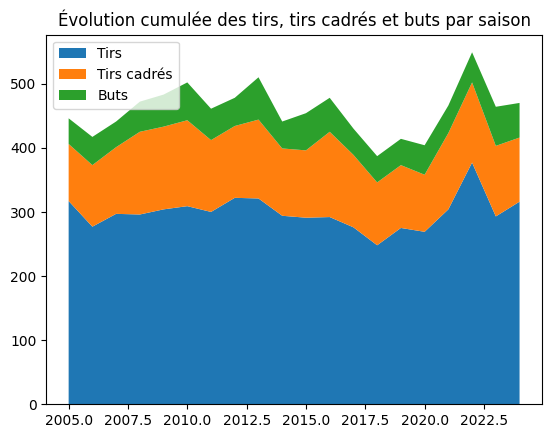

In [ ]:
x=df_stats["saison"]

plt.stackplot(x, df_stats["tirs_tot"] - df_stats["tirs_cadres_tot"], df_stats["tirs_cadres_tot"] - df_stats["buts_marques_tot"], df_stats["buts_marques_tot"], labels=['Tirs','Tirs cadrés','Buts'])
plt.title("Évolution cumulée des tirs, tirs cadrés et buts par saison")
plt.legend(loc='upper left')

**4. Matrice de corrélation**

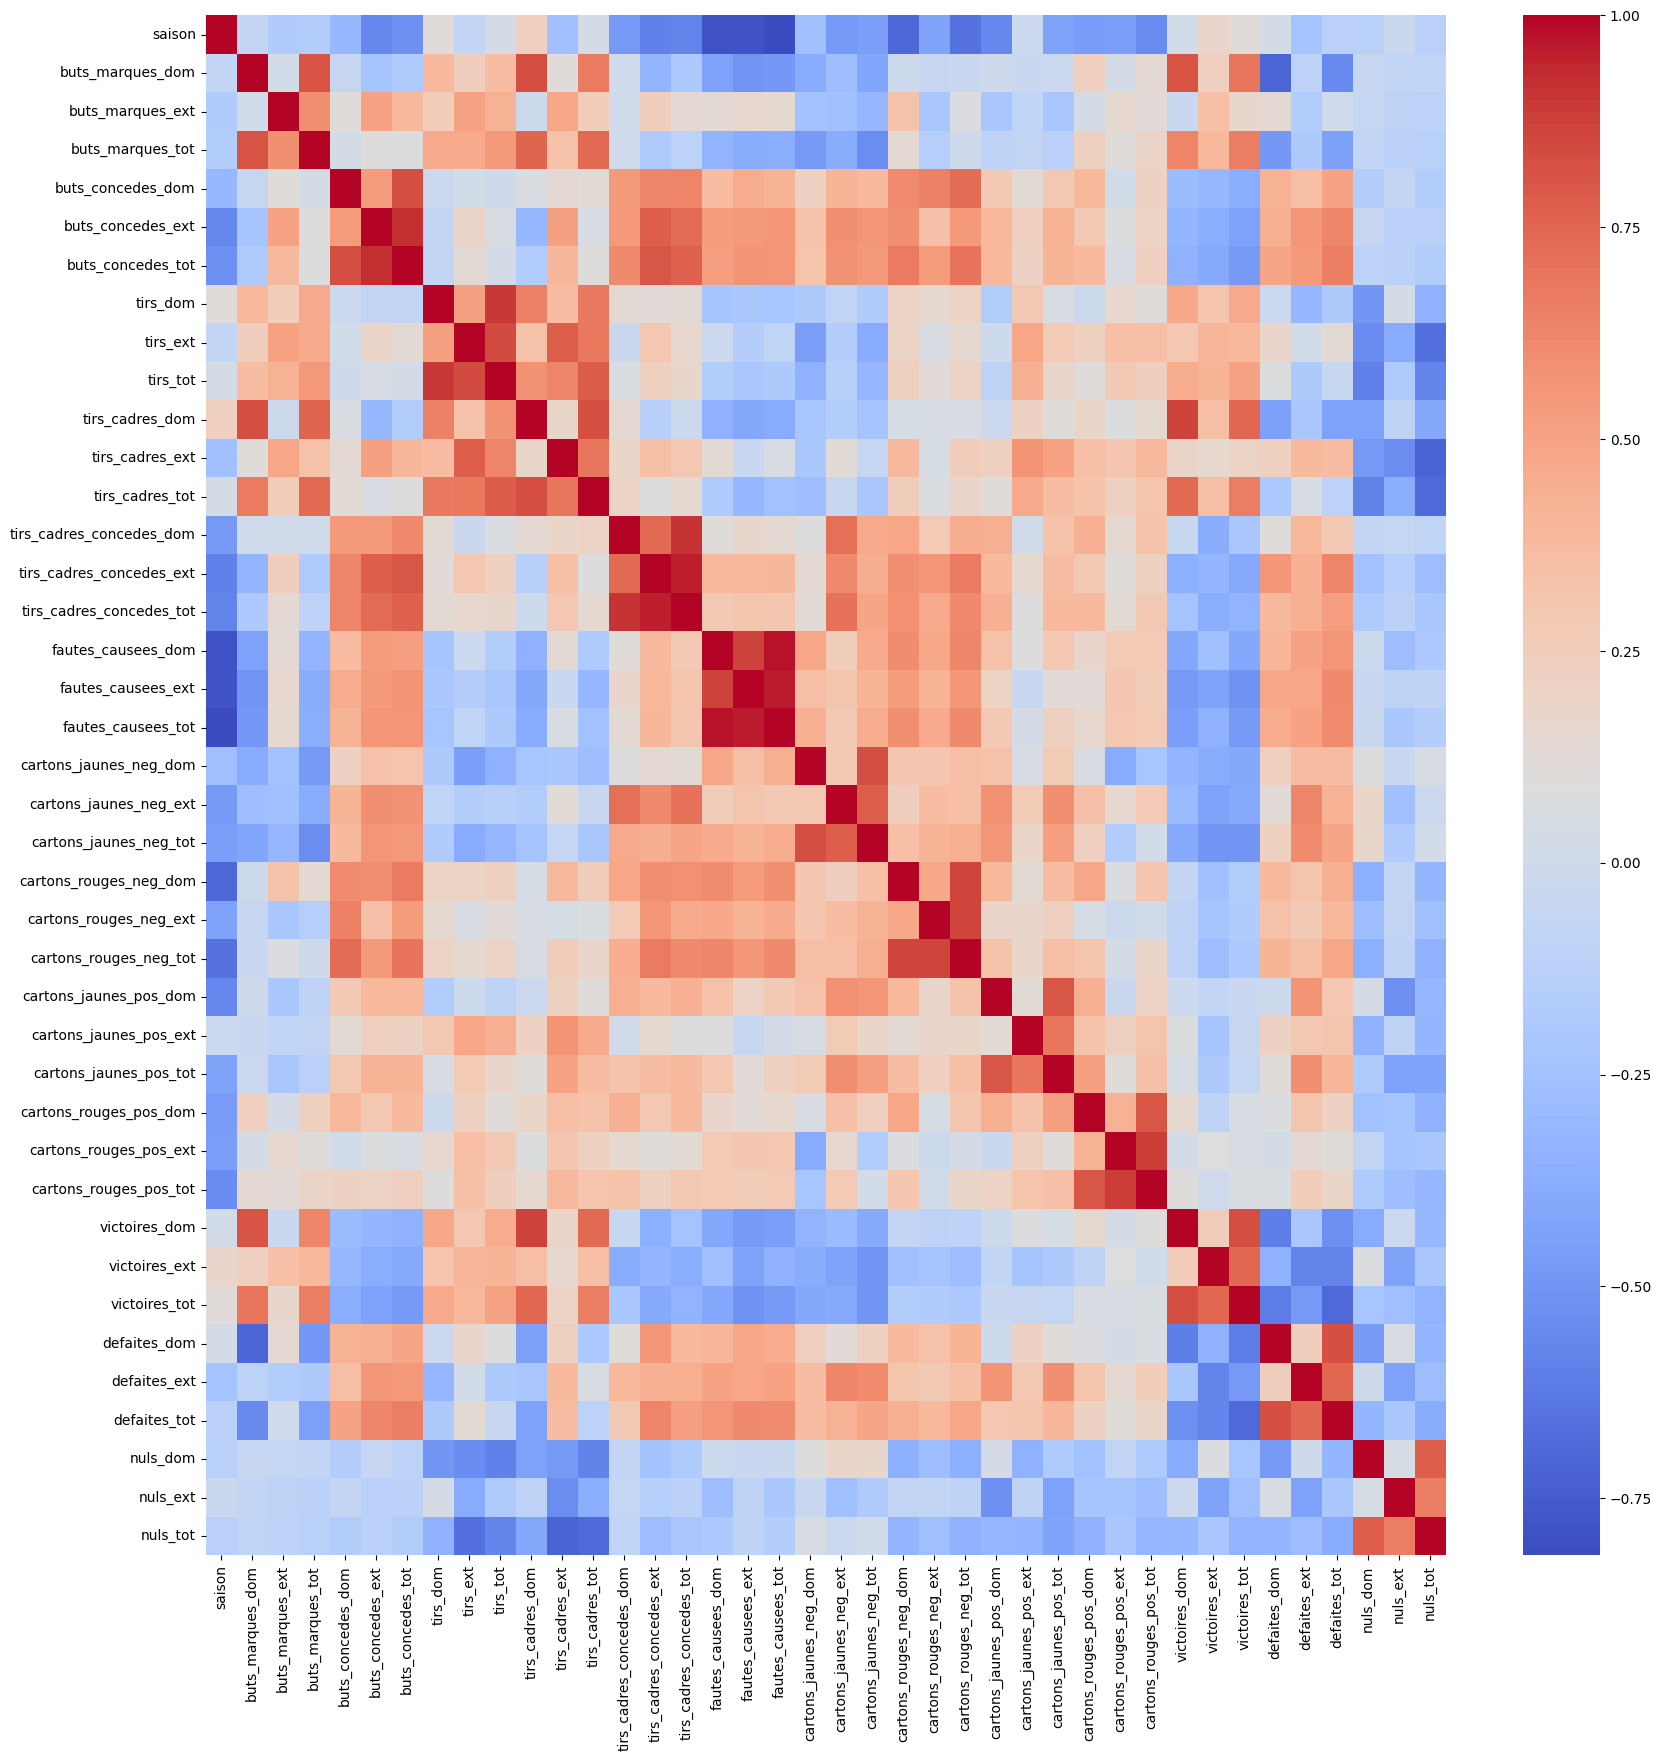

In [ ]:
matrice_corr = df_stats.corr()
plt.figure(figsize=(20,20))
sns.heatmap(matrice_corr, cmap="coolwarm")
plt.show()

**V. Modèle de régression linéaire**

Prédiction du nombre de buts qui seront marqués lors de la saison 2025-2026 en se basant sur les statistiques de tirs et tirs cadrés des saisons précédentes

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

df_stats = pd.DataFrame(stats)

X = df_stats[["tirs_tot", "tirs_cadres_tot"]]
Y = df_stats["buts_marques_tot"]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

imputer = SimpleImputer(strategy="mean")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

selector = SelectKBest(score_func=f_regression, k=2).set_output(transform="pandas")
X_train_filtered = selector.fit_transform(X_train_scaled, y_train)
X_test_filtered = selector.transform(X_test_scaled)


model = LinearRegression()
model.fit(X_train_filtered, y_train)

pred_test = model.predict(X_test_filtered)
mse = mean_squared_error(y_test, pred_test)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, pred_test)
r2   = r2_score(y_test, pred_test)

print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

moy_tirs = df_stats["tirs_tot"].mean()
moy_cadres = df_stats["tirs_cadres_tot"].mean()

future_df = pd.DataFrame([{"tirs_tot": moy_tirs, "tirs_cadres_tot": moy_cadres}])

future_scaled = scaler.transform(future_df)
future_filtered = selector.transform(future_scaled)

pred_2026 = model.predict(future_filtered)[0]
print(f"\nPrédiction des buts marqués par {team} en 2025-2026 : {pred_2026:.2f}")

MSE : 43.93
RMSE : 6.63
MAE  : 6.37
R²   : 0.0893

Prédiction des buts marqués par Ath Bilbao en 2025-2026 : 50.60


**VI. Modèle de régression linéaire avec validation temporelle**

Prédiction du nombre de victoires pour la saison 2025-2026 à partir de plusieurs variables statistiques avec prédiction de chaque saison en s'entraînant uniquement sur les saisons précédentes.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
import numpy as np

feature_cols = [
    "victoires_tot",
    "buts_concedes_tot",
    "tirs_tot",
    "tirs_cadres_tot",
    "tirs_cadres_concedes_tot",
    "fautes_causees_tot",
    "cartons_jaunes_neg_tot",
    "cartons_rouges_neg_tot",
    "cartons_jaunes_pos_tot",
    "cartons_rouges_pos_tot",
]

X_data = df_stats[feature_cols].iloc[:-1].reset_index(drop=True)
Y_data = df_stats["victoires_tot"].iloc[1:].reset_index(drop=True)

imputer = SimpleImputer(strategy="mean")
X_data = pd.DataFrame(imputer.fit_transform(X_data), columns=X_data.columns)

predictions = []
true_values = []

MIN_TRAIN = 5

for i in range(MIN_TRAIN, len(X_data)):

    X_train = X_data.iloc[:i]
    y_train = Y_data.iloc[:i]

    X_test = X_data.iloc[i:i+1]
    y_true = Y_data.iloc[i]

    scaler = StandardScaler().set_output(transform="pandas")
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = Ridge(alpha=1.0)
    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)[0]

    predictions.append(pred)
    true_values.append(y_true)

    print(f"\nSaison prédite: {df_stats['saison'].iloc[i]}-{df_stats['saison'].iloc[i] + 1}")
    print(f"- Victoires réelles : {y_true}")
    print(f"- Victoires prédites : {pred:.2f}")

mse  = mean_squared_error(true_values, predictions)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(true_values, predictions)
r2   = r2_score(true_values, predictions)

print(f"\nMSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

X_final_train = X_data
y_final_train = Y_data

X_future = df_stats[feature_cols].iloc[-1:]

scaler_final = StandardScaler().set_output(transform="pandas")
X_final_train_scaled = scaler_final.fit_transform(X_final_train)
X_future_scaled = scaler_final.transform(X_future)

model_final = Ridge(alpha=1.0)
model_final.fit(X_final_train_scaled, y_final_train)

pred_2026 = model_final.predict(X_future_scaled)[0]

print(f"\nVictoires totales prédites pour {team} en 2025-2026: {max(0, round(pred_2026, 2)):.2f}")


Saison prédite: 1998-1999
- Victoires réelles : 12
- Victoires prédites : 15.47

Saison prédite: 1999-2000
- Victoires réelles : 11
- Victoires prédites : 16.24

Saison prédite: 2000-2001
- Victoires réelles : 14
- Victoires prédites : 14.18

Saison prédite: 2001-2002
- Victoires réelles : 15
- Victoires prédites : 15.45

Saison prédite: 2002-2003
- Victoires réelles : 15
- Victoires prédites : 15.07

Saison prédite: 2003-2004
- Victoires réelles : 14
- Victoires prédites : 14.21

Saison prédite: 2004-2005
- Victoires réelles : 11
- Victoires prédites : 14.30

Saison prédite: 2005-2006
- Victoires réelles : 10
- Victoires prédites : 12.56

Saison prédite: 2006-2007
- Victoires réelles : 13
- Victoires prédites : 1.82

Saison prédite: 2007-2008
- Victoires réelles : 12
- Victoires prédites : 11.91

Saison prédite: 2008-2009
- Victoires réelles : 15
- Victoires prédites : 12.82

Saison prédite: 2009-2010
- Victoires réelles : 18
- Victoires prédites : 14.44

Saison prédite: 2010-2011
- 

**VII. Deuxième équipe**

Choix de la deuxième équipe, avec laquelle la première sera comparée ainsi que de la localisation du futur match entre ces deux équipes

In [ ]:
team_2 = input("Saisissez l'adversaire qui vous intérresse : ")
loc = input("Le match se joue à domicile ou à l'extérieur ? : ")

loc = loc.strip().lower()

if loc in ["domicile", "dom", "home", "h", "d"]:
    loc = "H"
elif loc in ["exterieur", "ext", "away", "a", "e"]:
    loc = "A"

Saisissez l'adversaire qui vous intérresse : Real Madrid
Le match se joue à domicile ou à l'extérieur ? : ext


**VIII. Récupérations des données**


Création de la liste dont chaque élément est un dictionnaire lié à une saison (donc à un fichier csv) de la deuxième équipe suivi du remplissage de cette dernière avec à partir des fichiers csv

In [ ]:
stats_2 = []

for season in seasons:

  stats_2.append({
      "saison": season,
      "buts_marques_dom": 0,
      "buts_marques_ext": 0,
      "buts_marques_tot": 0,
      "buts_concedes_dom": 0,
      "buts_concedes_ext": 0,
      "buts_concedes_tot": 0,
      "tirs_dom": 0,
      "tirs_ext": 0,
      "tirs_tot": 0,
      "tirs_cadres_dom": 0,
      "tirs_cadres_ext": 0,
      "tirs_cadres_tot": 0,
      "tirs_cadres_concedes_dom": 0,
      "tirs_cadres_concedes_ext": 0,
      "tirs_cadres_concedes_tot": 0,
      "fautes_causees_dom": 0,
      "fautes_causees_ext": 0,
      "fautes_causees_tot": 0,
      "cartons_jaunes_neg_dom": 0,
      "cartons_jaunes_neg_ext": 0,
      "cartons_jaunes_neg_tot": 0,
      "cartons_rouges_neg_dom": 0,
      "cartons_rouges_neg_ext": 0,
      "cartons_rouges_neg_tot": 0,
      "cartons_jaunes_pos_dom": 0,
      "cartons_jaunes_pos_ext": 0,
      "cartons_jaunes_pos_tot": 0,
      "cartons_rouges_pos_dom": 0,
      "cartons_rouges_pos_ext": 0,
      "cartons_rouges_pos_tot": 0,
      "victoires_dom": 0,
      "victoires_ext": 0,
      "victoires_tot": 0,
      "defaites_dom": 0,
      "defaites_ext": 0,
      "defaites_tot": 0,
      "nuls_dom": 0,
      "nuls_ext": 0,
      "nuls_tot": 0,
  })

In [ ]:
statistics(stats_2, team_2)

**IX. Calcul des chances de victoire de chacunes des deux équipes lors d'un futur match à une localisation prédéfinie**

**1. Comparaison des statistiques**

Comparaison des statistiques des deux équipes en fonction du lieu du match (domicile ou extérieur) et attribution des points pondérés à chaque équipe selon leurs performances

In [ ]:
counter_1 = 0
counter_2 = 0

if loc == "H":

  if stats[-1]["buts_marques_dom"] > stats_2[-1]["buts_marques_ext"]:
    counter_1 += 4
  elif stats[-1]["buts_marques_dom"] < stats_2[-1]["buts_marques_ext"]:
    counter_2 += 4

  if stats[-1]["buts_concedes_dom"] > stats_2[-1]["buts_concedes_ext"]:
    counter_2 += 4
  elif stats[-1]["buts_concedes_dom"] < stats_2[-1]["buts_concedes_ext"]:
    counter_1 += 4

  if stats[-1]["tirs_dom"] > stats_2[-1]["tirs_ext"]:
    counter_1 += 1
  elif stats[-1]["tirs_dom"] < stats_2[-1]["tirs_ext"]:
    counter_2 += 1

  if stats[-1]["tirs_cadres_dom"] > stats_2[-1]["tirs_cadres_ext"]:
    counter_1 += 3
  elif stats[-1]["tirs_cadres_dom"] < stats_2[-1]["tirs_cadres_ext"]:
    counter_2 += 3

  if stats[-1]["tirs_cadres_concedes_dom"] > stats_2[-1]["tirs_cadres_concedes_ext"]:
    counter_2 += 3
  else:
    counter_1 += 3

  if stats[-1]["cartons_jaunes_neg_dom"] > stats_2[-1]["cartons_jaunes_neg_ext"]:
    counter_2 += 2
  elif stats[-1]["cartons_jaunes_neg_dom"] < stats_2[-1]["cartons_jaunes_neg_ext"]:
    counter_1 += 2

  if stats[-1]["cartons_rouges_neg_dom"] > stats_2[-1]["cartons_rouges_neg_ext"]:
      counter_2 += 4
  elif stats[-1]["cartons_rouges_neg_dom"] < stats_2[-1]["cartons_rouges_neg_ext"]:
    counter_1 += 4

  if stats[-1]["cartons_jaunes_pos_dom"] > stats_2[-1]["cartons_jaunes_pos_ext"]:
    counter_1 += 2
  elif stats[-1]["cartons_jaunes_pos_dom"] < stats_2[-1]["cartons_jaunes_pos_ext"]:
    counter_2 += 2

  if stats[-1]["cartons_rouges_pos_dom"] > stats_2[-1]["cartons_rouges_pos_ext"]:
      counter_1 += 4
  elif stats[-1]["cartons_rouges_pos_dom"] < stats_2[-1]["cartons_rouges_pos_ext"]:
    counter_2 += 4

  if stats[-1]["victoires_dom"] > stats_2[-1]["victoires_ext"]:
      counter_1 += 5
  elif stats[-1]["victoires_dom"] < stats_2[-1]["victoires_ext"]:
    counter_2 += 5

  if stats[-1]["defaites_dom"] > stats_2[-1]["defaites_ext"]:
      counter_2 += 5
  elif stats[-1]["defaites_dom"] < stats_2[-1]["defaites_ext"]:
    counter_1 += 5


elif loc == "A":

  if stats[-1]["buts_marques_ext"] > stats_2[-1]["buts_marques_dom"]:
    counter_1 += 4
  elif stats[-1]["buts_marques_ext"] < stats_2[-1]["buts_marques_dom"]:
    counter_2 += 4

  if stats[-1]["buts_concedes_ext"] > stats_2[-1]["buts_concedes_dom"]:
    counter_2 += 4
  elif stats[-1]["buts_concedes_ext"] < stats_2[-1]["buts_concedes_dom"]:
    counter_1 += 4

  if stats[-1]["tirs_ext"] > stats_2[-1]["tirs_dom"]:
    counter_1 += 1
  elif stats[-1]["tirs_ext"] < stats_2[-1]["tirs_dom"]:
    counter_2 += 1

  if stats[-1]["tirs_cadres_ext"] > stats_2[-1]["tirs_cadres_dom"]:
    counter_1 += 3
  elif stats[-1]["tirs_cadres_ext"] < stats_2[-1]["tirs_cadres_dom"]:
    counter_2 += 3

  if stats[-1]["tirs_cadres_concedes_ext"] > stats_2[-1]["tirs_cadres_concedes_dom"]:
    counter_2 += 3
  elif stats[-1]["tirs_cadres_concedes_ext"] < stats_2[-1]["tirs_cadres_concedes_dom"]:
    counter_1 += 3

  if stats[-1]["cartons_jaunes_neg_ext"] > stats_2[-1]["cartons_jaunes_neg_dom"]:
    counter_2 += 2
  elif stats[-1]["cartons_jaunes_neg_ext"] < stats_2[-1]["cartons_jaunes_neg_dom"]:
    counter_1 += 2

  if stats[-1]["cartons_rouges_neg_ext"] > stats_2[-1]["cartons_rouges_neg_dom"]:
      counter_2 += 4
  elif stats[-1]["cartons_rouges_neg_ext"] < stats_2[-1]["cartons_rouges_neg_dom"]:
    counter_1 += 4

  if stats[-1]["cartons_jaunes_pos_ext"] > stats_2[-1]["cartons_jaunes_pos_dom"]:
    counter_1 += 2
  elif stats[-1]["cartons_jaunes_pos_ext"] < stats_2[-1]["cartons_jaunes_pos_dom"]:
    counter_2 += 2

  if stats[-1]["cartons_rouges_pos_ext"] > stats_2[-1]["cartons_rouges_pos_dom"]:
      counter_1 += 4
  elif stats[-1]["cartons_rouges_pos_ext"] < stats_2[-1]["cartons_rouges_pos_dom"]:
    counter_2 += 4

  if stats[-1]["victoires_ext"] > stats_2[-1]["victoires_dom"]:
      counter_1 += 5
  elif stats[-1]["victoires_ext"] < stats_2[-1]["victoires_dom"]:
    counter_2 += 5

  if stats[-1]["defaites_ext"] > stats_2[-1]["defaites_dom"]:
      counter_2 += 5
  elif stats[-1]["defaites_ext"] < stats_2[-1]["defaites_dom"]:
    counter_1 += 5

**2. Normalisation et détermination du vainqueur**

Conversion des scores en pourcentages répartis sur 70% avec ajout de la probabilité fixe de match nul puis détermination du vainqueur

In [ ]:
total = counter_1 + counter_2

counter_1 = (counter_1 / total) * 70
counter_2 = (counter_2 / total) * 70

draw = 30

if counter_1 > counter_2:
  winner = team
else:
  winner = team_2

**3. Visualisation et interprétation des probabilités de résultat**

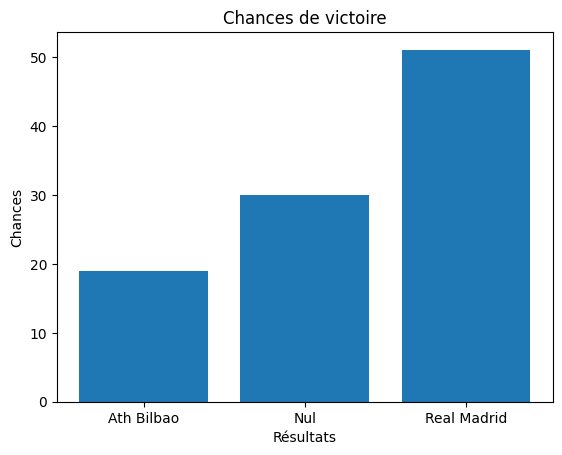

Le pourcentage en faveur d'une victoire de Ath Bilbao est de 18.92%, tandis qu'il est de 51.08% pour une victoire de Real Madrid. Il est probable d'assister à une victoire de Real Madrid


In [ ]:
labels = [team, "Nul", team_2]
values = [counter_1, draw, counter_2]

x_pos = np.arange(len(labels))

plt.bar(x_pos, values)

plt.title('Chances de victoire')
plt.xlabel('Résultats')
plt.ylabel('Chances')

plt.xticks(x_pos, labels)

plt.show()

if abs(counter_1 - counter_2) < 10:
  print(f"Le pourcentage en faveur d'une victoire de {team} est de {counter_1:.2f}%, tandis qu'il est de {counter_2:.2f}% pour une victoire de {team_2}. Il est probable d'assister à un match nul.")
else:
  print(f"Le pourcentage en faveur d'une victoire de {team} est de {counter_1:.2f}%, tandis qu'il est de {counter_2:.2f}% pour une victoire de {team_2}. Il est probable d'assister à une victoire de {winner}")

**4. Calcul des cotes**

In [ ]:
if counter_1 == 0:
  counter_1 += 1
elif counter_2 == 0:
  counter_2 += 1

cote_team_1 = 100 / counter_1
cote_draw = 100 / draw
cote_team_2 = 100 / counter_2

print(f"Voici les côtes du match :\n- Victoire de {team} : {cote_team_1:.2f}\n- Match nul : {cote_draw:.2f}\n- Victoire de {team_2} : {cote_team_2:.2f}")

Voici les côtes du match :
- Victoire de Ath Bilbao : 5.29
- Match nul : 3.33
- Victoire de Real Madrid : 1.96
